In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Leer el archivo GeoJSON
# Reemplaza 'tu_archivo.geojson' con la ruta real de tu archivo
gdf = gpd.read_file('colombia_municipios.geojson')

gdf.shape

(1122, 6)

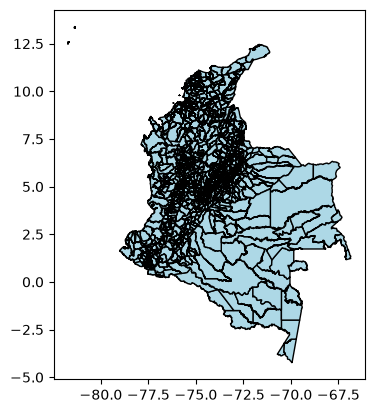

In [4]:
# 2. Crear el plot básico
# Puedes personalizarlo un poco añadiendo colores y bordes para que se vea mejor
gdf.plot(color='lightblue', edgecolor='black')

# 3. Mostrar el gráfico
plt.show()

In [5]:
import hashlib
import geopandas as gpd

INPUT_FILE = "colombia_municipios.geojson"
OUTPUT_FILE = "colombia_municipios.parquet"

print("1. Leyendo GeoJSON original...")
gdf = gpd.read_file(INPUT_FILE)

# Opcional pero recomendado: simplificar vértices (tolerancia en grados decimales)
# 0.001 ≈ 100m de precisión, ideal para mapas temáticos sin deformar fronteras
gdf["geometry"] = gdf["geometry"].simplify(tolerance=0.001, preserve_topology=True)

print("2. Guardando en GeoParquet...")
gdf.to_parquet(OUTPUT_FILE, index=False, compression="snappy")

# 3. Calcular SHA-256
sha256_hash = hashlib.sha256()
with open(OUTPUT_FILE, "rb") as f:
    for byte_block in iter(lambda: f.read(4096), b""):
        sha256_hash.update(byte_block)

print(f"Archivo generado: {OUTPUT_FILE}")
print(f"SHA-256: {sha256_hash.hexdigest()}")

1. Leyendo GeoJSON original...
2. Guardando en GeoParquet...
Archivo generado: colombia_municipios.parquet
SHA-256: 1a7d3a2150b5c38f03faf28561f3565a9bfb5894701b159e082eca9b2b6cfd83


In [6]:
import hashlib
import geopandas as gpd

INPUT_FILE = "colombia_municipios.geojson"
OUTPUT_FILE = "colombia_municipios.parquet"

print("1. Leyendo GeoJSON original...")
gdf = gpd.read_file(INPUT_FILE)

# Opcional pero recomendado: simplificar vértices (tolerancia en grados decimales)
# 0.001 ≈ 100m de precisión, ideal para mapas temáticos sin deformar fronteras
gdf["geometry"] = gdf["geometry"].simplify(tolerance=0.001, preserve_topology=True)

print("2. Guardando en GeoParquet...")
gdf.to_parquet(OUTPUT_FILE, index=False, compression="snappy")

# 3. Calcular SHA-256
sha256_hash = hashlib.sha256()
with open(OUTPUT_FILE, "rb") as f:
    for byte_block in iter(lambda: f.read(4096), b""):
        sha256_hash.update(byte_block)

print(f"Archivo generado: {OUTPUT_FILE}")
print(f"SHA-256: {sha256_hash.hexdigest()}")

1. Leyendo GeoJSON original...
2. Guardando en GeoParquet...
Archivo generado: colombia_municipios.parquet
SHA-256: 1a7d3a2150b5c38f03faf28561f3565a9bfb5894701b159e082eca9b2b6cfd83


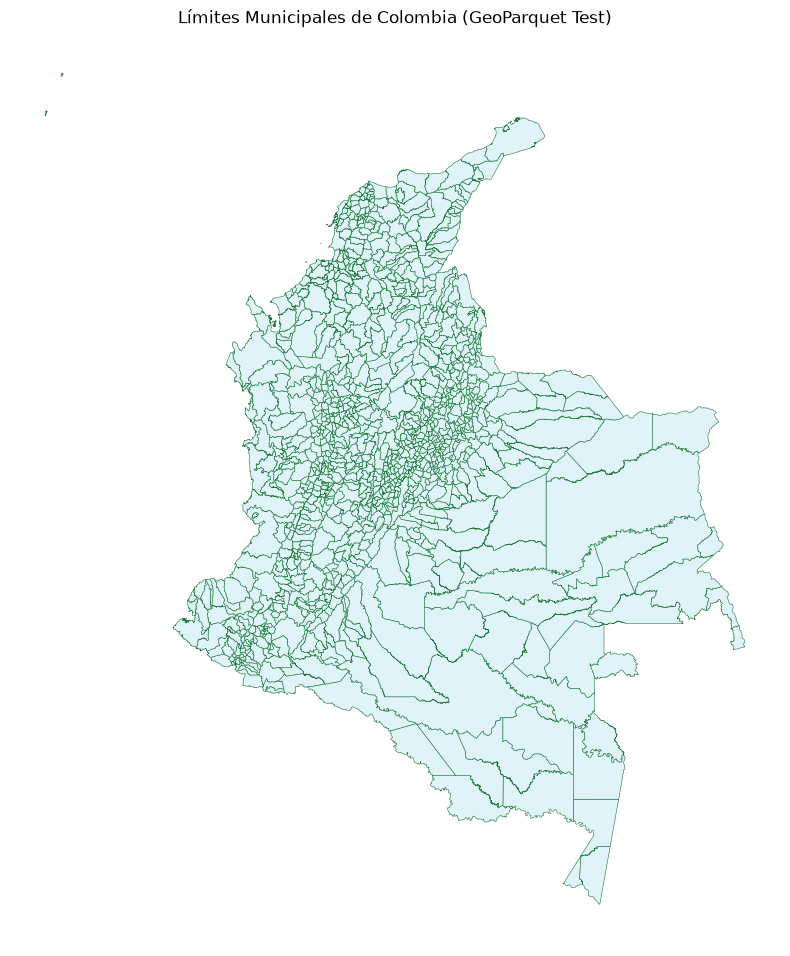

In [7]:
fig, ax = plt.subplots(figsize=(8, 10))

gdf.plot(
    ax=ax,
    color="#e0f3f8",
    edgecolor="#1b7837",
    linewidth=0.4
)

ax.set_title("Límites Municipales de Colombia (GeoParquet Test)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

[{'dataset_id': 'colombia_municipios', 'title': 'Límites Municipales de Colombia', 'description': 'Cartografía vectorial de los municipios de Colombia.', 'latest_version': '1.0.0'}]
Descargando colombia_municipios (colombia_municipios.parquet) desde GitHub...


<Axes: >

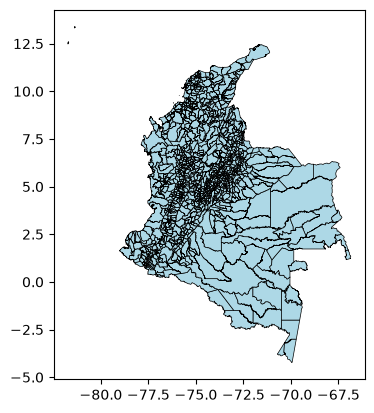

In [2]:
import pypoldata as ppd

# 1. Ver qué datasets existen
print(ppd.list_datasets())

# 2. Cargar directamente (lo descargará la primera vez a la caché)
gdf = ppd.load("colombia_municipios")

# 3. Graficar
gdf.plot(color="lightblue", edgecolor="black", linewidth=0.5)